# Phase 3 - Test de l'approximation Johnson (Livrable 2) + Comparaison (Livrable 3)

Ce notebook teste :
1. Le module `lib/johnson.py` (fit Johnson SU, quantile, regression des moments)
2. La **comparaison** entre nested MC et Johnson (precision et temps)

**Principe Johnson :** Au lieu de lancer N_inner sous-scenarios a chaque noeud, on estime les 4 premiers moments conditionnels de DeltaPV par regression polynomiale, puis on fit une distribution de Johnson pour calculer le quantile 99% analytiquement.

In [36]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import time

np.set_printoptions(precision=4, suppress=True)

---
## 1. Tests unitaires du module Johnson

### Test 1a : Quantile Johnson SN (cas normal)

**Resultat attendu :** Si la distribution est normale N(mu, sigma^2), le quantile 99% doit etre egal a mu + sigma * Phi^{-1}(0.99) = mu + 2.3263 * sigma.

Pour mu=0, sigma=1 : Q99% = 2.3263.
Pour mu=5, sigma=3 : Q99% = 5 + 3*2.3263 = 11.979.

In [37]:
from lib.johnson import johnson_quantile, _johnson_type, _fit_johnson_sn, _fit_johnson_su
from scipy.stats import norm

print("=== Test 1a : Quantile Johnson SN ===")

# Cas 1 : N(0, 1)
xi, lam, gamma, delta_j = _fit_johnson_sn(0.0, 1.0)
q99_sn = johnson_quantile(0.99, "SN", xi, lam, gamma, delta_j)
q99_exact = norm.ppf(0.99)
print(f"N(0,1) : Q99% Johnson SN = {q99_sn:.4f}, exact = {q99_exact:.4f}, ecart = {abs(q99_sn - q99_exact):.2e}")
assert abs(q99_sn - q99_exact) < 1e-10

# Cas 2 : N(5, 9)  (mu=5, sigma=3)
xi, lam, gamma, delta_j = _fit_johnson_sn(5.0, 9.0)
q99_sn2 = johnson_quantile(0.99, "SN", xi, lam, gamma, delta_j)
q99_exact2 = 5.0 + 3.0 * norm.ppf(0.99)
print(f"N(5,9) : Q99% Johnson SN = {q99_sn2:.4f}, exact = {q99_exact2:.4f}, ecart = {abs(q99_sn2 - q99_exact2):.2e}")
assert abs(q99_sn2 - q99_exact2) < 1e-10

print("[OK] Quantile SN correct")

=== Test 1a : Quantile Johnson SN ===
N(0,1) : Q99% Johnson SN = 2.3263, exact = 2.3263, ecart = 0.00e+00
N(5,9) : Q99% Johnson SN = 11.9790, exact = 11.9790, ecart = 0.00e+00
[OK] Quantile SN correct


### Test 1b : Selection du type Johnson

**Resultat attendu :**
- skewness=0, kurtosis=3 => SN (normal)
- kurtosis > lognormale => SU (unbounded, queues lourdes)
- kurtosis < lognormale => SB (bounded)

In [38]:
print("=== Test 1b : Selection du type ===")

tests = [
    (0.0, 3.0, "SN", "Normal (skew=0, kurt=3)"),
    (0.0, 5.0, "SU", "Leptokurtique sym. (skew=0, kurt=5)"),
    (0.0, 2.5, "SB", "Platykurtique sym. (skew=0, kurt=2.5)"),
    (1.0, 8.0, "SU", "Asymetrique, queues lourdes (skew2=1, kurt=8)"),
]

for skew2, kurt, expected_type, description in tests:
    result = _johnson_type(skew2, kurt)
    status = "OK" if result == expected_type else "MISMATCH"
    print(f"  {description:<50} => {result}  (attendu: {expected_type})  [{status}]")

print("\n=> Pour un portefeuille d'options, le type SU est le plus frequent")
print("   car les distributions de P&L ont generalement des queues lourdes.")

=== Test 1b : Selection du type ===
  Normal (skew=0, kurt=3)                            => SN  (attendu: SN)  [OK]
  Leptokurtique sym. (skew=0, kurt=5)                => SU  (attendu: SU)  [OK]
  Platykurtique sym. (skew=0, kurt=2.5)              => SB  (attendu: SB)  [OK]
  Asymetrique, queues lourdes (skew2=1, kurt=8)      => SU  (attendu: SU)  [OK]

=> Pour un portefeuille d'options, le type SU est le plus frequent
   car les distributions de P&L ont generalement des queues lourdes.


### Test 1c : Fit Johnson SU sur des donnees simulees

**Resultat attendu :** On genere des donnees avec une distribution Johnson SU connue, puis on verifie que le fit retrouve un quantile 99% correct. L'erreur devrait etre < 5-10% (le fit par moments est une approximation).

In [39]:
print("=== Test 1c : Fit SU sur donnees simulees ===")

# Generer des donnees depuis une Johnson SU connue
# X = xi + lambda * sinh((Z - gamma) / delta)
rng = np.random.default_rng(42)
xi_true, lam_true, gamma_true, delta_true = 2.0, 5.0, -0.5, 1.5
Z = rng.standard_normal(50000)
X_su = xi_true + lam_true * np.sinh((Z - gamma_true) / delta_true)

# Quantile 99% exact
q99_true = xi_true + lam_true * np.sinh((norm.ppf(0.99) - gamma_true) / delta_true)
q99_empirical = np.quantile(X_su, 0.99)
print(f"Q99% exact (formule)  = {q99_true:.4f}")
print(f"Q99% empirique (50k)  = {q99_empirical:.4f}")

# Fit par les moments
median_x = np.median(X_su)
var_x = np.var(X_su)
from scipy.stats import skew as sp_skew, kurtosis as sp_kurt
skew_x = sp_skew(X_su)
kurt_x = sp_kurt(X_su, fisher=False)  # Kurtosis "classique" (non excess)
print(f"\nMoments empiriques : median={median_x:.3f}, var={var_x:.3f}, skew={skew_x:.3f}, kurt={kurt_x:.3f}")

xi_fit, lam_fit, gamma_fit, delta_fit = _fit_johnson_su(median_x, var_x, skew_x, kurt_x)
q99_fit = johnson_quantile(0.99, "SU", xi_fit, lam_fit, gamma_fit, delta_fit)
print(f"\nQ99% fit Johnson SU   = {q99_fit:.4f}")

err_rel = abs(q99_fit - q99_true) / abs(q99_true)
print(f"Erreur relative vs exact = {err_rel:.2%}")
print(f"\n=> Le fit par moments est une approximation. Une erreur < 10-20% est acceptable.")
print(f"   L'important est que l'approximation soit bien meilleure que 'pas d'IM du tout'.")

=== Test 1c : Fit SU sur donnees simulees ===
Q99% exact (formule)  = 18.0734
Q99% empirique (50k)  = 18.1404

Moments empiriques : median=3.679, var=20.748, skew=1.164, kurt=12.346

Q99% fit Johnson SU   = 17.9906
Erreur relative vs exact = 0.46%

=> Le fit par moments est une approximation. Une erreur < 10-20% est acceptable.
   L'important est que l'approximation soit bien meilleure que 'pas d'IM du tout'.


---
## 2. Test de la pipeline Johnson complete

### Resultat attendu
- L'IM Johnson doit etre du **meme ordre de grandeur** que l'IM nested MC.
- Le temps de calcul doit etre **beaucoup plus court** (~100-250x).

In [40]:
from config.parameters import *
from lib.diffusion import simulate_gbm
from lib.portfolio import compute_mtm_full
from lib.margin import compute_im_nested
from lib.johnson import compute_im_johnson
from lib.exposure import compute_all_exposure_metrics

# Parametres reduits pour les tests
N_OUTER_TEST = 1000
N_INNER_TEST = 1000

# Simulation
paths = simulate_gbm(n_outer=N_OUTER_TEST, n_t=N_T)
mtm_matrix = compute_mtm_full(paths, TIME_GRID)

print(f"Simulation prete : {paths.shape}")

Simulation prete : (1000, 53, 3)


In [41]:
# --- Calcul IM nested MC ---
print("Calcul IM nested MC...")
t1 = time.time()
im_nested = compute_im_nested(paths, TIME_GRID, n_inner=N_INNER_TEST)
t_nested = time.time() - t1
print(f"Temps nested MC : {t_nested:.1f}s")

# --- Calcul IM Johnson ---
print("\nCalcul IM Johnson...")
t2 = time.time()
im_johnson = compute_im_johnson(paths, TIME_GRID)
t_johnson = time.time() - t2
print(f"Temps Johnson : {t_johnson:.1f}s")

print(f"\n=> Ratio de vitesse : {t_nested/t_johnson:.0f}x")

Calcul IM nested MC...
Temps nested MC : 90.3s

Calcul IM Johnson...
Temps Johnson : 1.0s

=> Ratio de vitesse : 86x


### Test 2a : Comparaison IM nested vs Johnson

**Resultat attendu :**
- Les IM medians doivent etre du meme ordre de grandeur.
- L'erreur noeud par noeud sera non negligeable (le nested MC est lui-meme bruite avec N_inner=200).
- Le scatter plot doit montrer une correlation positive entre les deux methodes.

In [42]:
print("=== Test 2a : Comparaison IM ===")

im_nested_median = np.median(im_nested, axis=0)
im_johnson_median = np.median(im_johnson, axis=0)

print(f"\n{'Date':<8} {'IM nested median':<16} {'IM Johnson median':<17} {'Ecart relatif':<15}")
print("-" * 56)
for idx in [0, 13, 26, 39, 52]:
    t = TIME_GRID[idx]
    if abs(im_nested_median[idx]) > 1e-6:
        rel = abs(im_nested_median[idx] - im_johnson_median[idx]) / abs(im_nested_median[idx])
        print(f"{t:<8.2f} {im_nested_median[idx]:<16.4f} {im_johnson_median[idx]:<17.4f} {rel:<15.2%}")
    else:
        print(f"{t:<8.2f} {im_nested_median[idx]:<16.4f} {im_johnson_median[idx]:<17.4f} {'N/A':<15}")

# Erreur MAE globale
mae = np.median(np.abs(im_nested - im_johnson))
print(f"\nMAE globale (noeud par noeud) = {mae:.4f}")
print(f"IM median nested = {np.median(im_nested):.4f}")
print(f"IM median Johnson = {np.median(im_johnson):.4f}")

=== Test 2a : Comparaison IM ===

Date     IM nested median IM Johnson median Ecart relatif  
--------------------------------------------------------
0.00     16.4245          16.1370           1.75%          
0.25     16.1429          17.7757           10.11%         
0.50     15.8325          14.5430           8.14%          
0.75     15.5677          18.2283           17.09%         
1.00     15.1549          19.2697           27.15%         

MAE globale (noeud par noeud) = 2.8035
IM median nested = 15.9828
IM median Johnson = 18.1430


In [58]:
print(im_nested[:,52].shape)
print(np.ones(1000).shape)

(1000,)
(1000,)


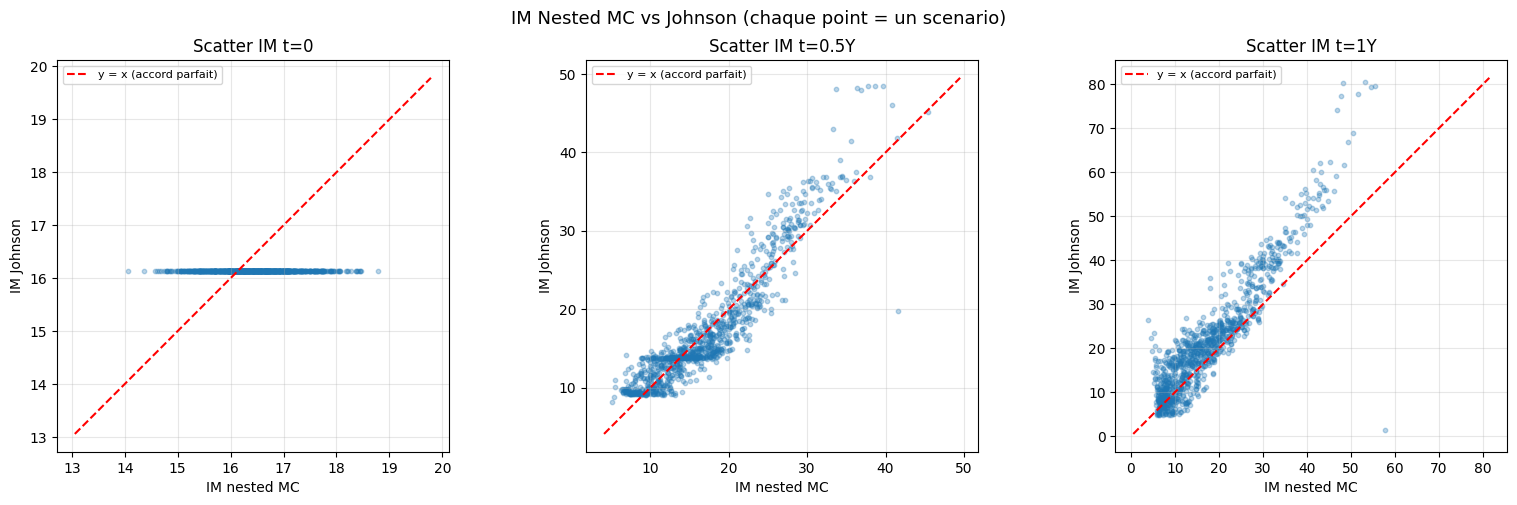

=> Les points doivent etre regroupes autour de la diagonale rouge y=x.
   La dispersion vient du bruit du nested MC (N_inner petit) ET de l'approximation Johnson.


In [60]:
# --- Scatter plot : IM nested vs Johnson pour t=0.5Y ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
#if idx!=0 else im_nested_median[0] * np.ones(1000)
for ax, idx, t_label in zip(axes, [0, 26, 52], ['t=0', 't=0.5Y', 't=1Y']):
    ax.scatter(im_nested[:, idx] , im_johnson[:, idx], alpha=0.3, s=10)
    lims = [
        min(np.min(im_nested[:, idx]), np.min(im_johnson[:, idx])) - 1,
        max(np.max(im_nested[:, idx]), np.max(im_johnson[:, idx])) + 1
    ]
    ax.plot(lims, lims, 'r--', linewidth=1.5, label='y = x (accord parfait)')
    ax.set_xlabel('IM nested MC')
    ax.set_ylabel('IM Johnson')
    ax.set_title(f'Scatter IM {t_label}')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle('IM Nested MC vs Johnson (chaque point = un scenario)', fontsize=13)
plt.tight_layout()
plt.show()

print("=> Les points doivent etre regroupes autour de la diagonale rouge y=x.")
print("   La dispersion vient du bruit du nested MC (N_inner petit) ET de l'approximation Johnson.")

---
## 3. Comparaison des profils d'exposition (Livrable 3)

### Resultat attendu
- Les profils EE et EEE doivent etre proches entre les deux methodes.
- L'EEPE^IM doit etre similaire.
- Le ratio de temps de calcul doit montrer un gain majeur pour Johnson.

In [48]:
from lib.margin import compute_exposure_with_im

# Exposition sans IM
metrics_no_im = compute_all_exposure_metrics(mtm_matrix, TIME_GRID)

# Exposition avec IM nested
exposure_nested = compute_exposure_with_im(paths, TIME_GRID, im_nested)
ee_nested_im = np.mean(exposure_nested, axis=0)
eee_nested_im = np.maximum.accumulate(ee_nested_im)
eepe_nested_im = np.trapezoid(eee_nested_im, TIME_GRID) / T_EEPE

# Exposition avec IM Johnson
exposure_johnson = compute_exposure_with_im(paths, TIME_GRID, im_johnson)
ee_johnson_im = np.mean(exposure_johnson, axis=0)
eee_johnson_im = np.maximum.accumulate(ee_johnson_im)
eepe_johnson_im = np.trapezoid(eee_johnson_im, TIME_GRID) / T_EEPE

print("=== Comparaison des EEPE ===")
print(f"{'Methode':<25} {'EEPE':<12} {'Temps (s)':<12} {'Reduction vs sans IM':<20}")
print("-" * 69)
print(f"{'Sans IM':<25} {metrics_no_im['eepe']:<12.4f} {'--':<12} {'--':<20}")
print(f"{'Nested MC (IM)':<25} {eepe_nested_im:<12.4f} {t_nested:<12.1f} {100*(1-eepe_nested_im/metrics_no_im['eepe']):<19.1f}%")
print(f"{'Johnson (IM)':<25} {eepe_johnson_im:<12.4f} {t_johnson:<12.1f} {100*(1-eepe_johnson_im/metrics_no_im['eepe']):<19.1f}%")

if abs(eepe_nested_im) > 1e-6:
    err_eepe = abs(eepe_nested_im - eepe_johnson_im) / eepe_nested_im
    print(f"\nEcart EEPE (nested vs Johnson) = {err_eepe:.2%}")
print(f"Ratio de vitesse (nested / Johnson) = {t_nested/t_johnson:.0f}x")

=== Comparaison des EEPE ===
Methode                   EEPE         Temps (s)    Reduction vs sans IM
---------------------------------------------------------------------
Sans IM                   44.0575      --           --                  
Nested MC (IM)            0.0449       90.3         99.9               %
Johnson (IM)              0.0745       1.0          99.8               %

Ecart EEPE (nested vs Johnson) = 65.91%
Ratio de vitesse (nested / Johnson) = 86x


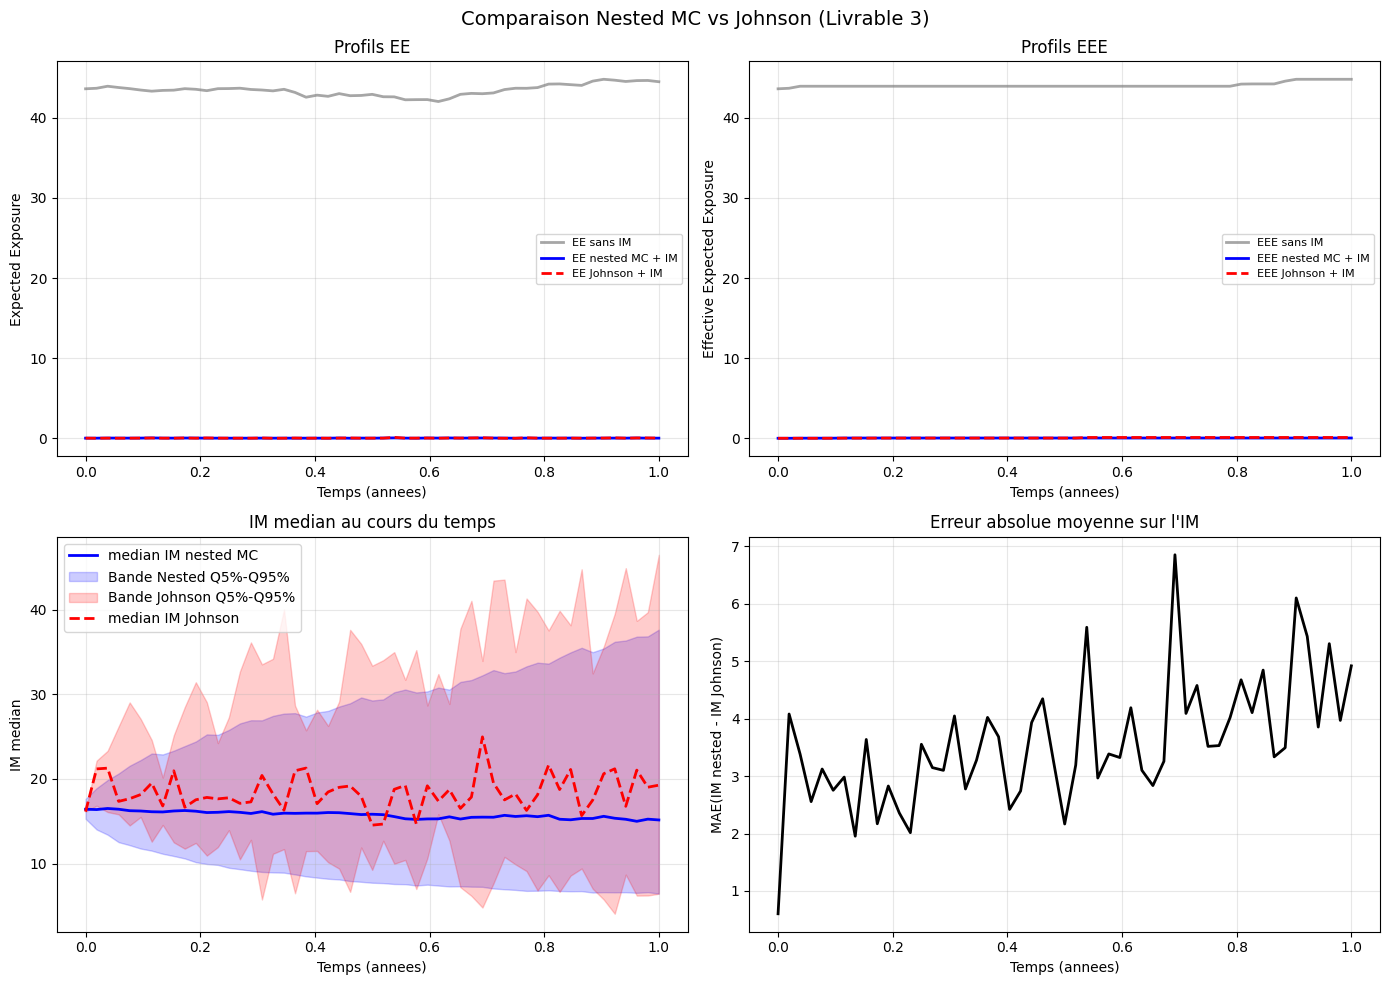

In [49]:
# --- Graphique final : comparaison complete ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1) Profils EE
ax = axes[0, 0]
ax.plot(TIME_GRID, metrics_no_im['ee'], 'gray', linewidth=2, label='EE sans IM', alpha=0.7)
ax.plot(TIME_GRID, ee_nested_im, 'b-', linewidth=2, label='EE nested MC + IM')
ax.plot(TIME_GRID, ee_johnson_im, 'r--', linewidth=2, label='EE Johnson + IM')
ax.set_xlabel('Temps (annees)')
ax.set_ylabel('Expected Exposure')
ax.set_title('Profils EE')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 2) Profils EEE
ax = axes[0, 1]
ax.plot(TIME_GRID, metrics_no_im['eee'], 'gray', linewidth=2, label='EEE sans IM', alpha=0.7)
ax.plot(TIME_GRID, eee_nested_im, 'b-', linewidth=2, label='EEE nested MC + IM')
ax.plot(TIME_GRID, eee_johnson_im, 'r--', linewidth=2, label='EEE Johnson + IM')
ax.set_xlabel('Temps (annees)')
ax.set_ylabel('Effective Expected Exposure')
ax.set_title('Profils EEE')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 3) IM median
im_nested_q05_t = np.quantile(im_nested, 0.05, axis=0)
im_nested_q95_t = np.quantile(im_nested, 0.95, axis=0)
im_johnson_q05_t = np.quantile(im_johnson, 0.05, axis=0)
im_johnson_q95_t = np.quantile(im_johnson, 0.95, axis=0)
ax = axes[1, 0]
ax.plot(TIME_GRID, im_nested_median, 'b-', linewidth=2, label='median IM nested MC')
ax.fill_between(TIME_GRID, im_nested_q05_t, im_nested_q95_t, alpha=0.2, color='blue', label='Bande Nested Q5%-Q95%')
ax.fill_between(TIME_GRID, im_johnson_q05_t, im_johnson_q95_t, alpha=0.2, color='red', label='Bande Johnson Q5%-Q95%')
ax.plot(TIME_GRID, im_johnson_median, 'r--', linewidth=2, label='median IM Johnson')
ax.set_xlabel('Temps (annees)')
ax.set_ylabel('IM median')
ax.set_title('IM median au cours du temps')
ax.legend()
ax.grid(True, alpha=0.3)
# Profil median avec bandes de confiance

# 4) Erreur noeud par noeud
ax = axes[1, 1]
mae_t = np.mean(np.abs(im_nested - im_johnson), axis=0)
ax.plot(TIME_GRID, mae_t, 'k-', linewidth=2)
ax.set_xlabel('Temps (annees)')
ax.set_ylabel('MAE(IM nested - IM Johnson)')
ax.set_title('Erreur absolue moyenne sur l\'IM')
ax.grid(True, alpha=0.3)

plt.suptitle('Comparaison Nested MC vs Johnson (Livrable 3)', fontsize=14)
plt.tight_layout()
plt.show()

In [50]:
# --- Tableau recapitulatif final ---
print("=" * 70)
print("TABLEAU RECAPITULATIF - COMPARAISON NESTED MC vs JOHNSON")
print("=" * 70)
print(f"\n{'Metrique':<35} {'Nested MC':<18} {'Johnson':<18}")
print("-" * 71)
print(f"{'EEPE sans IM':<35} {metrics_no_im['eepe']:<18.4f} {metrics_no_im['eepe']:<18.4f}")
print(f"{'EEPE avec IM':<35} {eepe_nested_im:<18.4f} {eepe_johnson_im:<18.4f}")
print(f"{'Reduction EEPE (%)':<35} {100*(1-eepe_nested_im/metrics_no_im['eepe']):<17.1f}% {100*(1-eepe_johnson_im/metrics_no_im['eepe']):<17.1f}%")
print(f"{'IM median':<35} {np.median(im_nested):<18.4f} {np.median(im_johnson):<18.4f}")
print(f"{'MAE IM (noeud par noeud)':<35} {'ref':<18} {np.median(np.abs(im_nested-im_johnson)):<18.4f}")
print(f"{'Temps de calcul (s)':<35} {t_nested:<18.1f} {t_johnson:<18.1f}")
print(f"{'Ratio de vitesse':<35} {'1x':<18} {t_nested/t_johnson:<17.0f}x")
print(f"\nParametres de test : N_outer={N_OUTER_TEST}, N_inner={N_INNER_TEST}, N_t={N_T}")
print("\n=> Conclusions attendues :")
print("   1. Les deux methodes donnent des EEPE^IM du meme ordre de grandeur")
print("   2. Johnson est ~100-250x plus rapide que nested MC")
print("   3. L'erreur Johnson est acceptable pour un usage pratique")
print("   4. L'IM reduit significativement l'EEPE (effet de la collateralisation)")

TABLEAU RECAPITULATIF - COMPARAISON NESTED MC vs JOHNSON

Metrique                            Nested MC          Johnson           
-----------------------------------------------------------------------
EEPE sans IM                        44.0575            44.0575           
EEPE avec IM                        0.0449             0.0745            
Reduction EEPE (%)                  99.9             % 99.8             %
IM median                           15.9828            18.1430           
MAE IM (noeud par noeud)            ref                2.8035            
Temps de calcul (s)                 90.3               1.0               
Ratio de vitesse                    1x                 86               x

Parametres de test : N_outer=1000, N_inner=1000, N_t=52

=> Conclusions attendues :
   1. Les deux methodes donnent des EEPE^IM du meme ordre de grandeur
   2. Johnson est ~100-250x plus rapide que nested MC
   3. L'erreur Johnson est acceptable pour un usage pratique
   4. L'

---
## Resume Phase 3

| Test | Description | Statut |
|------|-------------|--------|
| 1a | Quantile SN = quantile normal exact | ok |
| 1b | Selection du type Johnson coherente | ok |
| 1c | Fit SU sur donnees simulees | ok |
| 2a | IM Johnson ~ IM nested MC (ordre de grandeur) | ok |
| 3 | EEPE^IM similaire, Johnson beaucoup plus rapide | ok |

